# Tiền xử lý dữ liệu Ames Housing
Notebook này tiếp nối các notebook EDA (`Khao_sat_bai_toan_va_tinh_chat_du_lieu`, `Phan_tich_don_bien`, `Phan_tich_da_bien`, `Gia_tri_thieu_va_ngoai_le`).
Mỗi quyết định xử lý bên dưới đều xuất phát từ một phát hiện của bước EDA:

| Phát hiện ở EDA | Quyết định xử lý |
|---|---|
| Id 524 và Id 1299 có GrLivArea > 4000 nhưng giá thấp bất thường (mục 5.4) | Loại khỏi tập huấn luyện |
| 19 cột thiếu, phần lớn là thiếu có cấu trúc (mục 5.2) | Điền theo ý nghĩa của từng biến trong `data_description.txt` |
| LotFrontage thiếu 17.7% và liên quan đến vị trí (mục 5.2) | Điền trung vị theo Neighborhood |
| SalePrice và các biến diện tích lệch phải (mục 3, 6) | Log-transform |
| MSSubClass là mã nhóm nhà (mục 2.2) | Chuyển thành biến phân loại |
| Các biến diện tích trùng thông tin (mục 4.2) | Tạo biến tổng hợp, để Feature Selection xử lý phần trùng còn lại |

Code xử lý nằm trong `tien_xu_ly.py` để dùng lại ở notebook đánh giá Feature Selection.

In [1]:
import json, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from scipy.stats import skew
from tien_xu_ly import *
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

train, test = doc_du_lieu('train.csv', 'test.csv')
print('train:', train.shape, '| test:', test.shape)
SUMMARY = {}

train: (1460, 81) | test: (1459, 80)


## 1. Giá trị thiếu và chiến lược xử lý
Bảng dưới liệt kê các cột thiếu ở tập train và test cùng cách xử lý được chọn (bám theo `data_description.txt`).

In [2]:
strategy = {}
for c in ['PoolQC','MiscFeature','Alley','Fence','MasVnrType','FireplaceQu','GarageType','GarageFinish','GarageQual','GarageCond',
          'BsmtExposure','BsmtFinType2','BsmtQual','BsmtCond','BsmtFinType1']:
    strategy[c] = "Nhãn 'None' (không có đặc điểm này)"
strategy['LotFrontage'] = 'Trung vị theo Neighborhood'
strategy['GarageYrBlt'] = 'Điền bằng YearBuilt (thêm cờ HasGarage)'
strategy['MasVnrArea'] = 'Điền 0 (không có veneer)'
strategy['Electrical'] = 'Điền mode (chỉ 1 dòng)'
for c in ['MSZoning','Utilities','Exterior1st','Exterior2nd','KitchenQual','Functional','SaleType']:
    strategy.setdefault(c, 'Điền mode (chỉ có ở tập test)')
for c in ['BsmtFinSF1','BsmtFinSF2','BsmtUnfSF','TotalBsmtSF','BsmtFullBath','BsmtHalfBath','GarageCars','GarageArea']:
    strategy.setdefault(c, 'Điền 0 (không có tầng hầm / garage)')

mt = train.isnull().sum(); mte = test.isnull().sum()
tab = pd.DataFrame({'Thiếu (train)': mt, '% train': (mt/len(train)*100).round(1), 'Thiếu (test)': mte.reindex(mt.index)})
tab = tab[(tab['Thiếu (train)']>0)].sort_values('Thiếu (train)', ascending=False)
tab['Cách xử lý'] = [strategy.get(c, '') for c in tab.index]
extra = [c for c in mte[mte>0].index if c not in tab.index]
tab2 = pd.DataFrame({'Thiếu (train)': 0, '% train': 0.0, 'Thiếu (test)': mte[extra], 'Cách xử lý': [strategy.get(c,'Điền mode/0') for c in extra]})
tab = pd.concat([tab, tab2])
tab.to_csv('ket_qua/bang_thieu_xu_ly.csv', encoding='utf-8-sig')
SUMMARY['n_missing_cols_train'] = int((mt>0).sum())
tab

,Thiếu (train),% train,Thiếu (test),Cách xử lý
PoolQC,1453,99.5,1456.0,Nhãn 'None' (không có đặc điểm này)
MiscFeature,1406,96.3,1408.0,Nhãn 'None' (không có đặc điểm này)
Alley,1369,93.8,1352.0,Nhãn 'None' (không có đặc điểm này)
Fence,1179,80.8,1169.0,Nhãn 'None' (không có đặc điểm này)
MasVnrType,872,59.7,894.0,Nhãn 'None' (không có đặc điểm này)
FireplaceQu,690,47.3,730.0,Nhãn 'None' (không có đặc điểm này)
LotFrontage,259,17.7,227.0,Trung vị theo Neighborhood
GarageType,81,5.5,76.0,Nhãn 'None' (không có đặc điểm này)
GarageYrBlt,81,5.5,78.0,Điền bằng YearBuilt (thêm cờ HasGarage)
GarageFinish,81,5.5,78.0,Nhãn 'None' (không có đặc điểm này)


## 2. Loại mẫu bất thường (Id 524 và Id 1299)
Lặp lại phép lọc ở mục 5.4 của báo cáo EDA rồi loại hai bản ghi này khỏi tập huấn luyện.

Mẫu bất thường: [524, 1299]
Kích thước trước / sau khi loại: (1460, 81) -> (1458, 81)
Tương quan GrLivArea - SalePrice: 0.709 -> 0.735


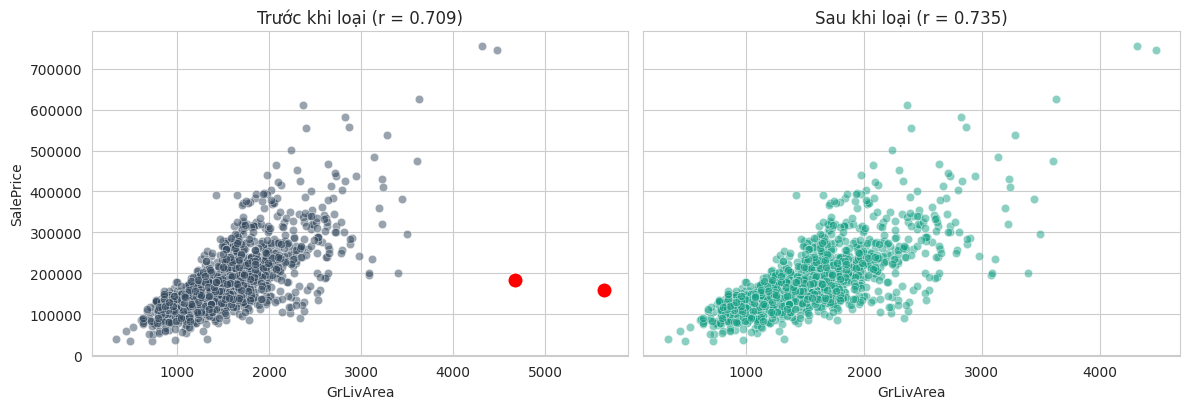

In [3]:
anom = train[(train['GrLivArea']>4000) & (train['SalePrice']<300000)]
print('Mẫu bất thường:', anom['Id'].tolist())
train_c = loai_mau_bat_thuong(train)
print('Kích thước trước / sau khi loại:', train.shape, '->', train_c.shape)

r_before = np.corrcoef(train['GrLivArea'], train['SalePrice'])[0,1]
r_after  = np.corrcoef(train_c['GrLivArea'], train_c['SalePrice'])[0,1]
print(f'Tương quan GrLivArea - SalePrice: {r_before:.3f} -> {r_after:.3f}')
SUMMARY.update(r_grliv_before=float(r_before), r_grliv_after=float(r_after), n_train_before=len(train), n_train_after=len(train_c))

fig, ax = plt.subplots(1, 2, figsize=(12,4.2), sharey=True)
sns.scatterplot(x='GrLivArea', y='SalePrice', data=train, alpha=.5, color='#34495e', ax=ax[0])
sns.scatterplot(x='GrLivArea', y='SalePrice', data=anom, color='red', s=120, ax=ax[0])
ax[0].set_title(f'Trước khi loại (r = {r_before:.3f})')
sns.scatterplot(x='GrLivArea', y='SalePrice', data=train_c, alpha=.5, color='#16a085', ax=ax[1])
ax[1].set_title(f'Sau khi loại (r = {r_after:.3f})')
plt.tight_layout(); plt.savefig('hinh/h1_ngoai_le.png', dpi=150); plt.show()

## 3. Biến mục tiêu: log-transform SalePrice
EDA cho thấy SalePrice lệch phải. Mô hình sẽ dự đoán `log1p(SalePrice)`; khi đánh giá, RMSE trên thang log tương ứng với RMSLE của cuộc thi Kaggle.

Skewness SalePrice: 1.879 | log1p(SalePrice): 0.121


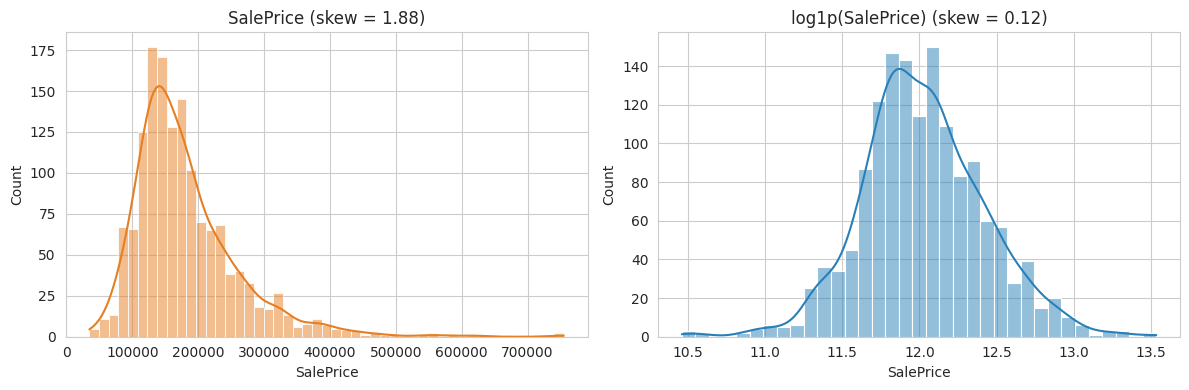

In [4]:
y_raw = train_c['SalePrice']; y_log = np.log1p(y_raw)
print(f'Skewness SalePrice: {skew(y_raw):.3f} | log1p(SalePrice): {skew(y_log):.3f}')
SUMMARY.update(skew_y_raw=float(skew(y_raw)), skew_y_log=float(skew(y_log)))
fig, ax = plt.subplots(1, 2, figsize=(12,4))
sns.histplot(y_raw, kde=True, color='#e67e22', ax=ax[0]); ax[0].set_title(f'SalePrice (skew = {skew(y_raw):.2f})')
sns.histplot(y_log, kde=True, color='#2980b9', ax=ax[1]); ax[1].set_title(f'log1p(SalePrice) (skew = {skew(y_log):.2f})')
plt.tight_layout(); plt.savefig('hinh/h2_log_saleprice.png', dpi=150); plt.show()

## 4. Làm sạch, mã hóa và tạo biến mới
`AmesCleaner` thực hiện điền thiếu, mã hóa thứ bậc, tạo biến mới và log-transform các biến định lượng lệch phải (skew > 0.75). Ở đây fit trên toàn bộ tập train chỉ để **quan sát**; ở notebook đánh giá, bước này được fit riêng trong từng fold để không rò rỉ dữ liệu.

In [5]:
cleaner = AmesCleaner().fit(train_c)
Xc = cleaner.transform(train_c)
print('Sau làm sạch:', Xc.shape, '| biến số:', len(cleaner.num_cols_), '| biến phân loại:', len(cleaner.cat_cols_))
print('Số ô còn thiếu:', int(Xc.isnull().sum().sum()))
print('Biến được log-transform (%d):' % len(cleaner.skewed_), cleaner.skewed_)

base = cleaner._basic(train_c.assign(LotFrontage=train_c['LotFrontage']))
rows = []
for c in cleaner.skewed_:
    rows.append([c, skew(base[c]), skew(np.log1p(base[c]))])
sk = pd.DataFrame(rows, columns=['Biến','Skew trước','Skew sau']).round(2).sort_values('Skew trước', ascending=False)
sk.to_csv('ket_qua/bang_skew.csv', index=False, encoding='utf-8-sig')
SUMMARY['n_log_features'] = len(cleaner.skewed_)
sk.head(10)

Sau làm sạch: (1458, 90) | biến số: 66 | biến phân loại: 24
Số ô còn thiếu: 0
Biến được log-transform (17): ['LotArea', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'MiscVal', 'TotalSF', 'TotalPorchSF']


,Biến,Skew trước,Skew sau
14,MiscVal,24.43,5.16
0,LotArea,12.56,-0.18
12,3SsnPorch,10.29,7.72
7,LowQualFinSF,9.00,7.45
3,BsmtFinSF2,4.25,2.52
13,ScreenPorch,4.11,3.14
11,EnclosedPorch,3.08,2.11
1,MasVnrArea,2.69,0.51
10,OpenPorchSF,2.34,-0.02
9,WoodDeckSF,1.54,0.16


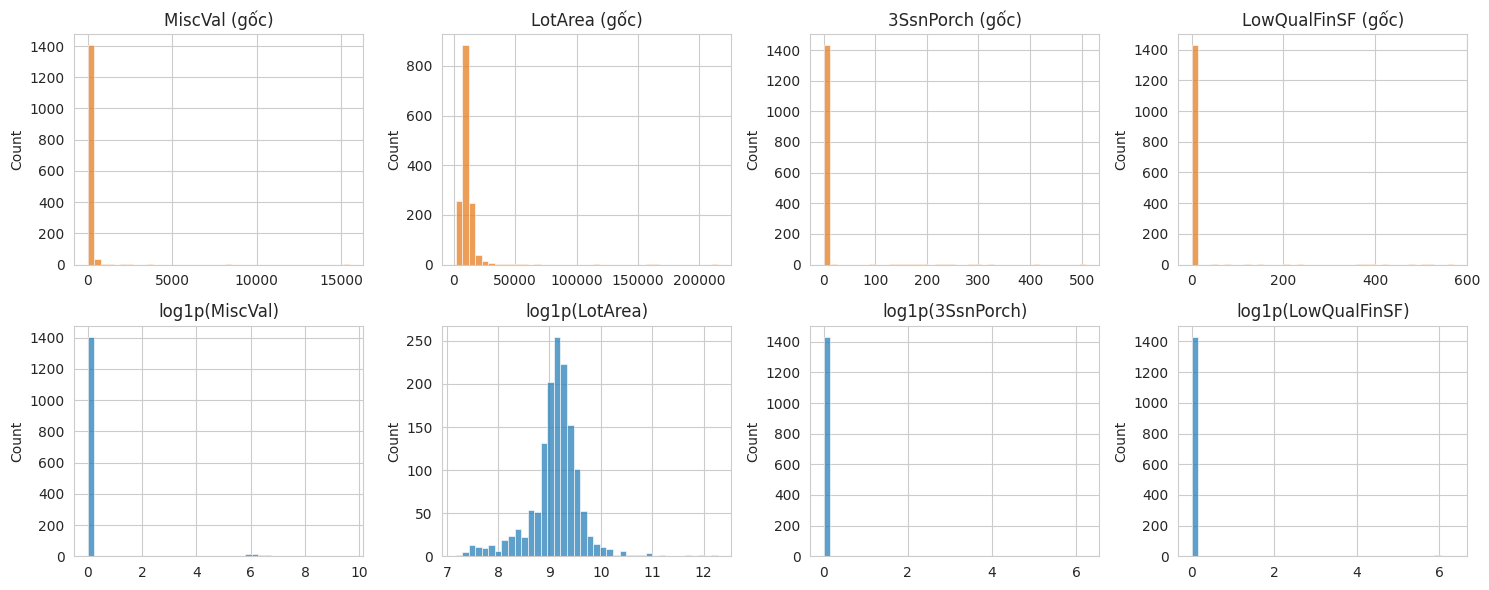

In [6]:
top = sk.head(4)['Biến'].tolist()
fig, ax = plt.subplots(2, 4, figsize=(15,6))
for j, c in enumerate(top):
    sns.histplot(base[c], bins=40, color='#e67e22', ax=ax[0,j]); ax[0,j].set_title(f'{c} (gốc)')
    sns.histplot(np.log1p(base[c]), bins=40, color='#2980b9', ax=ax[1,j]); ax[1,j].set_title(f'log1p({c})')
    ax[0,j].set_xlabel(''); ax[1,j].set_xlabel('')
plt.tight_layout(); plt.savefig('hinh/h3_log_bien.png', dpi=140); plt.show()

### Biến mới tạo thêm
EDA chỉ ra GarageCars - GarageArea, GrLivArea - TotRmsAbvGrd, TotalBsmtSF - 1stFlrSF cùng mô tả kích thước nhà. Các biến tổng hợp dưới đây gom thông tin đó lại; hệ số tương quan với `log1p(SalePrice)` cho thấy chúng có ích hay không.

In [7]:
new_cols = ['TotalSF','TotalBath','TotalPorchSF','HouseAge','RemodAge','IsRemodeled','HasGarage','HasBsmt','HasFireplace','HasPool','Has2ndFlr']
cmp = pd.DataFrame({'r với log1p(SalePrice)': [np.corrcoef(base[c], y_log)[0,1] for c in new_cols]}, index=new_cols).round(3)
orig = ['GrLivArea','TotalBsmtSF','1stFlrSF','GarageArea','OverallQual']
cmp_o = pd.DataFrame({'r với log1p(SalePrice)': [np.corrcoef(base[c], y_log)[0,1] for c in orig]}, index=orig).round(3)
cmp_all = pd.concat([cmp.assign(Loại='Biến mới'), cmp_o.assign(Loại='Biến gốc (đối chiếu)')]).sort_values('r với log1p(SalePrice)', ascending=False)
cmp_all.to_csv('ket_qua/bang_bien_moi.csv', encoding='utf-8-sig')
cmp_all

,r với log1p(SalePrice),Loại
TotalSF,0.825,Biến mới
OverallQual,0.821,Biến gốc (đối chiếu)
GrLivArea,0.725,Biến gốc (đối chiếu)
TotalBath,0.677,Biến mới
GarageArea,0.656,Biến gốc (đối chiếu)
TotalBsmtSF,0.648,Biến gốc (đối chiếu)
1stFlrSF,0.621,Biến gốc (đối chiếu)
HasFireplace,0.510,Biến mới
TotalPorchSF,0.400,Biến mới
HasGarage,0.323,Biến mới


## 5. Mã hóa one-hot, chuẩn hóa và kích thước dữ liệu cuối

In [8]:
prep = build_preprocessor()
X_all = prep.fit_transform(train_c, y_log)
X_test = prep.transform(test)
print('Ma trận đặc trưng train:', X_all.shape, '| test:', X_test.shape)
print('Còn thiếu (train/test):', int(X_all.isnull().sum().sum()), '/', int(X_test.isnull().sum().sum()))
n_cat_ohe = len(prep.named_steps['encode'].named_transformers_['cat'].get_feature_names_out())
n_num = len(prep.named_steps['clean'].num_cols_)
print(f'Gồm {n_num} biến số + {n_cat_ohe} cột one-hot từ {len(prep.named_steps["clean"].cat_cols_)} biến phân loại')
SUMMARY.update(n_features_final=int(X_all.shape[1]), n_num=int(n_num), n_ohe=int(n_cat_ohe),
               n_cat_vars=len(prep.named_steps['clean'].cat_cols_), n_test=int(X_test.shape[0]))
X_all.assign(log_SalePrice=y_log.values).to_csv('train_processed.csv', index=False)
X_test.to_csv('test_processed.csv', index=False)

Ma trận đặc trưng train: (1458, 229) | test: (1459, 229)
Còn thiếu (train/test): 0 / 0
Gồm 66 biến số + 163 cột one-hot từ 24 biến phân loại


## 6. Kiểm tra đa cộng tuyến sau tiền xử lý
Sau khi tạo biến và mã hóa, nhiều cặp biến vẫn tương quan rất cao. Đây là lý do cần Feature Selection ở bước sau.

In [9]:
num_only = X_all[[c for c in X_all.columns if X_all[c].nunique() > 2]]
cm = num_only.corr().abs()
pairs = [(a, b, cm.loc[a,b]) for i, a in enumerate(cm.columns) for b in cm.columns[i+1:] if cm.loc[a,b] > 0.85]
pairs = pd.DataFrame(pairs, columns=['Biến A','Biến B','|r|']).sort_values('|r|', ascending=False).round(3)
print('Số cặp biến có |r| > 0.85:', len(pairs))
SUMMARY['n_pairs_085'] = len(pairs)
pairs.head(12).to_csv('ket_qua/bang_cap_tuong_quan.csv', index=False, encoding='utf-8-sig')
pairs.head(12)

Số cặp biến có |r| > 0.85: 9


,Biến A,Biến B,|r|
0,YearBuilt,HouseAge,0.999
1,YearRemodAdd,RemodAge,0.998
7,GarageQual,GarageCond,0.959
8,PoolArea,PoolQC,0.932
6,GarageCars,GarageArea,0.887
3,BsmtFinType2,BsmtFinSF2,0.868
5,Fireplaces,FireplaceQu,0.865
4,GrLivArea,TotalSF,0.860
2,BsmtFinType1,BsmtFinSF1,0.852


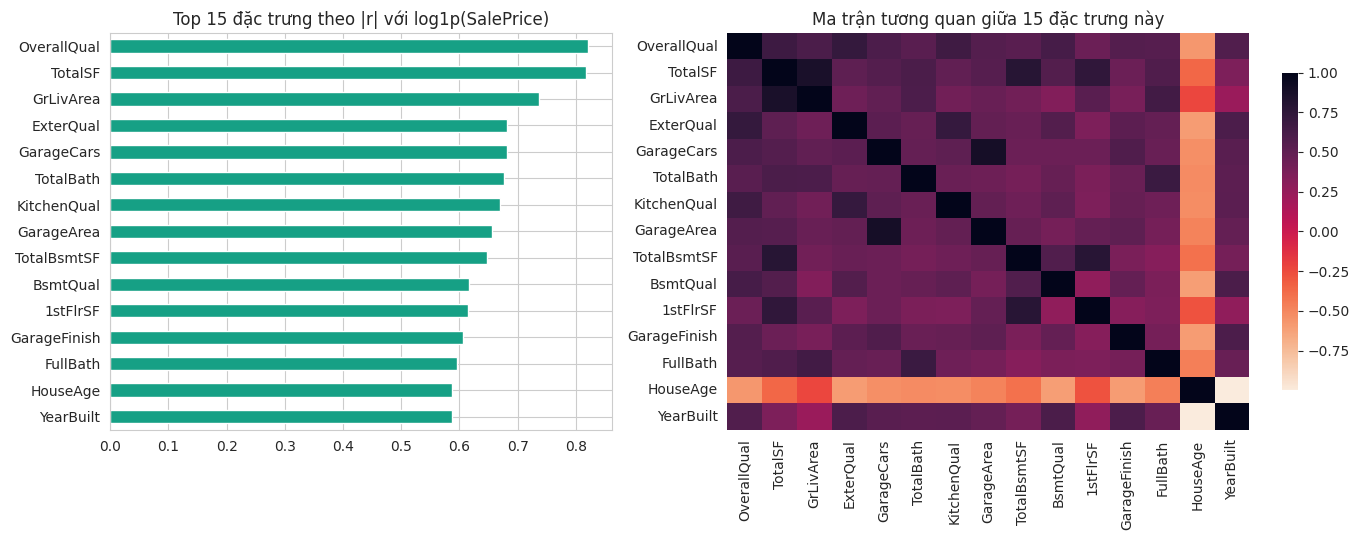

In [10]:
corr_y = X_all.corrwith(y_log).abs().sort_values(ascending=False)
top15 = corr_y.head(15).index.tolist()
fig, ax = plt.subplots(1, 2, figsize=(14,5.5), gridspec_kw={'width_ratios':[1,1.3]})
corr_y.head(15).sort_values().plot(kind='barh', color='#16a085', ax=ax[0]); ax[0].set_title('Top 15 đặc trưng theo |r| với log1p(SalePrice)')
sns.heatmap(X_all[top15].corr(), cmap='rocket_r', ax=ax[1], cbar_kws={'shrink':.8}); ax[1].set_title('Ma trận tương quan giữa 15 đặc trưng này')
plt.tight_layout(); plt.savefig('hinh/h4_tuong_quan_sau_xu_ly.png', dpi=140); plt.show()
SUMMARY['top15_corr'] = {k: float(v) for k, v in corr_y.head(15).items()}
json.dump(SUMMARY, open('ket_qua/tom_tat_tien_xu_ly.json','w'), ensure_ascii=False, indent=1)